# Graph Analysis Quick Example 📊

This notebook is a quick example of how you can load and explore the lex knowledge graph.

## Setup

In [2]:
import pandas as pd
from igraph import Graph

Load in the data

In [2]:
base_path = "../data/graph/graph"
edges_path = f"{base_path}/edges.tsv"
nodes_path = f"{base_path}/nodes.tsv"

edges = pd.read_csv(edges_path, index_col=0, sep="\t")
nodes = pd.read_csv(nodes_path, index_col=0, sep="\t")

Sample outputs to understand the shape of the data

In [3]:
edges.sample(5)

,source_id,target_id,type,context
2798726,http://www.legislation.gov.uk/id/ukpga/2021/14...,http://www.legislation.gov.uk/ukpga/2016/25,freetext_reference,A person may not be required under subsection ...
2322228,http://www.legislation.gov.uk/id/uksi/2009/325...,http://www.legislation.gov.uk/id/uksi/2009/3255,part_of,NaN
3074009,http://www.legislation.gov.uk/id/uksi/2018/58/...,http://www.legislation.gov.uk/id/uksi/2018/58,part_of,NaN
2265773,http://www.legislation.gov.uk/id/ukpga/2009/18...,http://www.legislation.gov.uk/id/ukpga/2009/18...,freetext_reference,This section and sections 23 and 24 come into ...
1997639,http://www.legislation.gov.uk/id/ukpga/2007/3/...,http://www.legislation.gov.uk/id/ukpga/2007/3/...,freetext_reference,This section has effect for determining — za w...


In [4]:
edges.target_id.value_counts()

target_id
http://www.legislation.gov.uk/id/ukpga/2020/1/schedule/5      12146
http://www.legislation.gov.uk/id/ukpga/2020/1                 11937
http://www.legislation.gov.uk/id/ukpga/2020/1/regulation/1     7124
http://www.legislation.gov.uk/id/ukpga/2006/46                 2973
http://www.legislation.gov.uk/id/ukpga/2010/4                  2715
                                                              ...  
http://www.legislation.gov.uk/id/eur/2007/502/section/4           1
http://www.legislation.gov.uk/id/eur/2007/655/section/4           1
http://www.legislation.gov.uk/id/eur/2007/1473/section/49         1
http://www.legislation.gov.uk/id/eur/2007/1114/section/1          1
http://www.legislation.gov.uk/id/ukpga/Geo3/51/115                1
Name: count, Length: 411489, dtype: int64

In [5]:
nodes.sample(5)

,id,label,type,text,extent,number_of_provisions,legislation_title,number
126365,http://www.legislation.gov.uk/id/apgb/Geo1/8/24,Piracy Act 1721 (repealed 5.11.1993),legislation,An Act for the more effectual suppressing of P...,"[['England', 'Wales', 'Scotland']]",9.0,Piracy Act 1721 (repealed 5.11.1993),NaN
339871,http://www.legislation.gov.uk/id/ukpga/2019/1/...,First-year allowances and first-year tax credits,section,First-year allowances and first-year tax credi...,[['United Kingdom']],NaN,Finance Act 2019,33
59400,http://www.legislation.gov.uk/id/ukpga/2015/2/...,Reporting restrictions: providers of informati...,schedule,Reporting restrictions: providers of informati...,[['United Kingdom']],NaN,Criminal Justice and Courts Act 2015,15
533737,http://www.legislation.gov.uk/id/uksi/1996/251...,"Housing Benefit: changes in thresholds for, an...",section,"Housing Benefit: changes in thresholds for, an...","[['England', 'Wales', 'Scotland']]",NaN,The Social Security (Non-Dependant Deductions)...,regulation-3
421633,http://www.legislation.gov.uk/id/ssi/2011/327/...,Identification of pigs moved on to a holding f...,section,Identification of pigs moved on to a holding f...,[['Scotland']],NaN,"The Pigs (Records, Identification and Movement...",article-11


## Cleaning and Validation

Perform some cleaning of the data and check for duplicates

In [6]:
# check for missing values in the id columns
edges[["source_id", "target_id"]].isna().sum()

source_id     0
target_id    20
dtype: int64

In [7]:
# drop rows with missing values
edges = edges.dropna(subset=["source_id", "target_id"])
edges[["source_id", "target_id"]].isna().sum()

source_id    0
target_id    0
dtype: int64

In [8]:
# check for duplicate edges
num_duplicates = edges.duplicated(subset=["source_id", "target_id", "type"]).sum()
print(f"Number of duplicate edges: {num_duplicates}")

Number of duplicate edges: 0


In [9]:
# get duplicate edges
duplicates = edges[
    edges.duplicated(subset=["source_id", "target_id", "type"], keep=False)
]
duplicates

,source_id,target_id,type,context


In [10]:
# drop duplicate edges
print(f"Number of edges before dropping duplicates: {edges.shape[0]}")
edges = edges.drop_duplicates(subset=["source_id", "target_id", "type"])
num_duplicates = edges.duplicated(subset=["source_id", "target_id", "type"]).sum()
print(f"Number of edges after dropping duplicates: {edges.shape[0]}")
print(f"Number of duplicate edges: {num_duplicates}")

Number of edges before dropping duplicates: 2224658
Number of edges after dropping duplicates: 2224658
Number of duplicate edges: 0


In [11]:
# reset node ids
nodes.index = range(nodes.shape[0])

# map edge source_id and target_id to source_idx and target_idx using the nodes dataframe
idx_map = nodes["id"].reset_index().set_index("id").to_dict()["index"]

# add any missing nodes from edges to the map
missing_nodes = set(edges["source_id"]).union(set(edges["target_id"])) - set(
    idx_map.keys()
)
for node in missing_nodes:
    idx_map[node] = len(idx_map)

## Add numerical indexes

Add numerical indices to the data

In [12]:
# map the source_id and target_id to the source_idx and target_idx
edges["source_idx"] = edges["source_id"].map(idx_map)
edges["target_idx"] = edges["target_id"].map(idx_map)

In [13]:
# convert idx from numpy into int
edges["source_idx"] = edges["source_idx"].astype(int)
edges["target_idx"] = edges["target_idx"].astype(int)

In [14]:
# reindex
edges = edges.reset_index(drop=True)

## Load into igraph for analysis

In [15]:
# Create edge list using the correct indices
edge_list = list(zip(edges["source_idx"], edges["target_idx"]))

# Create the graph
g = Graph(n=len(nodes), edges=edge_list, directed=True)

# Add node attributes
for col in nodes.columns:
    g.vs[col] = nodes[col].tolist()

# Add edge attributes
edge_attrs = edges.columns.difference(
    ["source_id", "source_idx", "target_id", "target_idx"]
)
for attr in edge_attrs:
    g.es[attr] = edges[attr].tolist()

# Verify graph integrity
assert g.vcount() >= len(nodes), "Number of vertices doesn't match"
assert g.ecount() == len(edges), "Number of edges doesn't match"

In [16]:
# check labels are aligned properly
assert nodes.loc[5].label == g.vs[5]["label"], (
    f"Node label does not match {nodes.loc[5].label} != {g.vs[5]['label']}"
)

In [17]:
print("\n# Graph summary")
print(g.summary())

# directed check
print("\n# Is directed")
print(g.is_directed())

# get connected components
components = g.connected_components(mode="weak")
print("\n# Connected components")
print(components.summary())

# describe sizes of connected components
component_sizes = components.sizes()
print(f"Mean component size: {sum(component_sizes) / len(component_sizes)}")
print(f"Max component size: {max(component_sizes)}")
print(f"Min component size: {min(component_sizes)}")

# get the largest component
print("\n# Largest component")
largest_component = components.giant()
print(largest_component.summary())

# find communities within the largest component
print("\n# Communities (Leiden)")
communities = largest_component.as_undirected().community_leiden(resolution=0.1)
print(communities.summary())
community_size = communities.sizes()
print(f"Max community size: {max(community_size)}")
print(f"Mean community size: {sum(community_size) / len(community_size)}")
print(f"Min community size: {min(community_size)}")

# get the top 100 highest degree nodes in the largest component
print("\n# Top 10 highest degree nodes")
top_degree_nodes = largest_component.degree()
top_degree_nodes = sorted(
    zip(largest_component.vs["label"], top_degree_nodes),
    key=lambda x: x[1],
    reverse=True,
)[:10]
print(top_degree_nodes)

# get the top 100 pagerank nodes
print("\n# Top 10 pagerank nodes")
top_pagerank_nodes = largest_component.pagerank()
top_pagerank_nodes = sorted(
    zip(largest_component.vs["label"], top_pagerank_nodes),
    key=lambda x: x[1],
    reverse=True,
)[:10]
print(top_pagerank_nodes)


# Graph summary
IGRAPH D--T 821103 2224658 -- 
+ attr: extent (v), id (v), label (v), legislation_title (v), number (v), number_of_provisions (v), text (v), type (v), context (e), type (e)

# Is directed
True

# Connected components
Clustering with 821103 elements and 38208 clusters
Mean component size: 21.490342336683415
Max component size: 462690
Min component size: 1

# Largest component
IGRAPH D--T 462690 1825124 -- 
+ attr: extent (v), id (v), label (v), legislation_title (v), number (v), number_of_provisions (v), text (v), type (v), context (e), type (e)

# Communities (Leiden)
Clustering with 462690 elements and 169762 clusters
Max community size: 267
Mean community size: 2.725521612610596
Min community size: 1

# Top 10 highest degree nodes
[('Consequential and transitional provision etc.', 12204), ('European Union (Withdrawal Agreement) Act 2020', 11937), ("Articles 33 and 34 shall not apply to supplies of second-hand goods, works of art, collectors' items...", 7124), ('Compa

In [18]:
# components sizes
print(pd.Series(component_sizes).describe())
print()
top_components = pd.Series(component_sizes).sort_values(ascending=False).head(100)
print(top_components.head(10))

print()
# community sizes
print(pd.Series(community_size).describe())
print()
top_communities = pd.Series(community_size).sort_values(ascending=False).head(100)
print(top_communities.head(10))

count     38208.000000
mean         21.490342
std        2367.177389
min           1.000000
25%           4.000000
50%           5.000000
75%           7.000000
max      462690.000000
dtype: float64

0        462690
1034       1506
7479        946
9097        877
12619       804
7131        738
3681        720
8609        712
5576        684
8577        673
dtype: int64

count    169762.000000
mean          2.725522
std           4.806453
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         267.000000
dtype: float64

22028     267
11826     193
102203    183
49874     154
8245      144
22530     144
54383     129
463       116
7511      114
109053    113
dtype: int64


In [19]:
eigenvector_centrality = largest_component.eigenvector_centrality()
top_influence_nodes = sorted(
    zip(largest_component.vs["label"], eigenvector_centrality),
    key=lambda x: x[1],
    reverse=True,
)[:10]

# split tuples into columns
pd.Series(top_influence_nodes).apply(pd.Series).rename(
    columns={0: "label", 1: "influence"}
)

,label,influence
0,Town and Country Planning (Scotland) Act 1972 ...,1.000000
1,Electricity Act 1989,0.950058
2,Gas Act 1995,0.918292
3,Restrictions on imposing certain custodial sen...,0.769584
4,Scrutineer’s report.,0.767595
5,Minor and consequential amendments,0.755535
6,Minor and Consequential Amendments,0.745226
7,Gas Act 1986,0.726668
8,Minor and consequential amendments.,0.716454
9,Applications for planning permission by statut...,0.708924


## Visualise the graph

We'll visualise an egonet of two nodes in the graph to understand how they are connected.

In [20]:
import gravis as gv
import numpy as np

# get egonet of node by label
n_hops = 2
ego_node_labels = ['Intellectual Property Act 2014', 'Data Protection Act 2018', 'Data Protection Act 1998']
node_indices = []
for node_label in ego_node_labels:
    node_idx = g.vs.find(label=node_label, type='legislation').index
    neighbours = g.neighborhood(node_idx, order=n_hops)
    node_indices.extend(neighbours)
node_indices = list(set(node_indices))
egonet = g.subgraph(node_indices)
plot_graph = egonet

# sizes
plot_graph.vs["size"] = plot_graph.eigenvector_centrality()
plot_graph.es["size"] = plot_graph.edge_betweenness()

# colours
node_colour_map = {
    "legislation": "green",
    "section": "orange",
    "schedule": "blue",
}
plot_graph.vs["color"] = [node_colour_map[type] for type in plot_graph.vs["type"]]

print(plot_graph.summary())

IGRAPH D--T 6066 24645 -- 
+ attr: color (v), extent (v), id (v), label (v), legislation_title (v), number (v), number_of_provisions (v), size (v), text (v), type (v), context (e), size (e), type (e)


In [ ]:
# Convert graph into gravis JSON format
# https://robert-haas.github.io/gravis-docs/code/examples/basic_use.html
# https://robert-haas.github.io/gravis-docs/rst/api/d3.html#gravis.d3

graph_json = {
    "graph": {
        "directed": plot_graph.is_directed(),
        "metadata": {
            "arrow_size": 2,
            "background_color": "white",
            "edge_label_size": 14,
            "edge_label_color": "black",
        },
        "nodes": {
            v.index: {
                "metadata": {
                    "label": (v["label"][:100] + "...")
                    if len(str(v["label"])) > 100
                    else v["label"],
                    "type": v["type"],
                    "size": v["size"],
                    "color": node_colour_map.get(v["type"], "black"),
                }
            }
            for v in plot_graph.vs
        },
        "edges": [
            {
                "source": e.source,
                "target": e.target,
                "metadata": {
                    "size": e["size"],
                },
            }
            for e in plot_graph.es
        ],
    }
}

# gv.d3 (2d graph viz), gv.three (3d graph viz)
gv.three(
    data=graph_json,
    # frame size
    graph_height=1200,
    layout_algorithm_active=True,
    # node settings
    node_label_data_source="label",
    node_label_size_factor=0.5,
    use_node_size_normalization=True,
    node_size_normalization_max=30,
    # edge settings
    edge_label_data_source="type",
    use_edge_size_normalization=True,
    edge_size_normalization_max=4,
    edge_curvature=0.3,
)


In [22]:
# Using the subgraph between IP and DPA
IP_vertex = plot_graph.vs.find(label="Intellectual Property Act 2014", type='legislation').index
IP_vertices = [v for v in plot_graph.vs if v["legislation_title"] == "Intellectual Property Act 2014"]
print(f"IP_vertex ID: {IP_vertex}, with {len(IP_vertices)} vertices")

DPA_vertex = plot_graph.vs.find(label="Data Protection Act 2018", type='legislation').index
DPA_98_vertex = plot_graph.vs.find(label="Data Protection Act 1998", type='legislation').index
DPA_vertices = [v for v in plot_graph.vs if v["legislation_title"] == "Data Protection Act 2018" or v["legislation_title"] == "Data Protection Act 1998"]
print(f"DPA_vertex ID: {DPA_vertex}, DPA_98_vertex ID: {DPA_98_vertex}, with {len(DPA_vertices)} vertices")


IP_vertex ID: 62, with 27 vertices
DPA_vertex ID: 2512, DPA_98_vertex ID: 3363, with 355 vertices


In [23]:
from igraph import plot
import matplotlib.pyplot as plt

def path_analysis(graph, source_vertex, target_vertex, cutoff_range=5):
    print("#" * 40)
    print(f"Path analysis between {graph.vs[source_vertex]['label']} and {graph.vs[target_vertex]['label']}")
    for i in range(1, cutoff_range + 1):
        paths = graph.get_all_simple_paths(source_vertex, target_vertex, cutoff=i, mode="all")
        print(f"Paths of length {i}: {len(paths)} between {graph.vs[source_vertex]['label']} and {graph.vs[target_vertex]['label']}")

    return paths

def print_paths_with_labels(graph, paths, num_paths=5):
    for path in paths[:num_paths]:
        # Get node labels
        path_labels = [graph.vs[node]["label"] for node in path]

        # Get edge labels
        edge_labels = []
        for i in range(len(path) - 1):
            try:
                edge = graph.es.find(_source=path[i], _target=path[i + 1])
                edge_label = edge["type"]
            except ValueError:
                try:
                    edge = graph.es.find(_source=path[i + 1], _target=path[i])
                    edge_label = "rev_" + edge["type"]  # reverse edge
                except ValueError:
                    raise ValueError("Edge not found")
            edge_labels.append(edge_label)

        # Combine node and edge labels
        path_str = " -- ".join(
            f"{path_labels[i]} --{edge_labels[i]}--> {path_labels[i + 1]}"
            for i in range(len(path_labels) - 1)
        )
        print("\nPath:")
        print(path_str)

def plot_paths(graph, paths, num_paths=10):
    # Limit number of paths
    paths = paths[:num_paths]

    combined_subgraph = graph.subgraph(set(node for path in paths for node in path))
    layout = combined_subgraph.layout("kk")
    
    # Increase node sizes
    node_sizes = [20 + 10 * np.log1p(degree) for degree in combined_subgraph.degree()]
    combined_subgraph.vs["size"] = node_sizes
    
    # Add colors for node types
    node_colors = [node_colour_map.get(node_type, "grey") for node_type in combined_subgraph.vs["type"]]
    combined_subgraph.vs["color"] = node_colors
    
    # Add colors for edge types
    edge_colors = {
        "part_of": "blue",
        "commentary_F": "red",
        "commentary_C": "green",
        "rev_commentary_F": "orange",
        "rev_commentary_C": "purple"
    }
    combined_subgraph.es["color"] = [edge_colors.get(edge_type, "black") for edge_type in combined_subgraph.es["type"]]
    
    fig, ax = plt.subplots(figsize=(15, 10))
    plot(combined_subgraph, layout=layout, target=ax, vertex_label=combined_subgraph.vs["label"], edge_label=combined_subgraph.es["type"])
    plt.show()


Path analysis between DPA 2018 and IP
########################################
Path analysis between Data Protection Act 2018 and Intellectual Property Act 2014
Paths of length 1: 0 between Data Protection Act 2018 and Intellectual Property Act 2014
Paths of length 2: 0 between Data Protection Act 2018 and Intellectual Property Act 2014
Paths of length 3: 0 between Data Protection Act 2018 and Intellectual Property Act 2014
Paths of length 4: 1907 between Data Protection Act 2018 and Intellectual Property Act 2014
Paths of length 5: 30770 between Data Protection Act 2018 and Intellectual Property Act 2014

Path:
Data Protection Act 2018 --rev_commentary_F--> Applications -- Applications --commentary_F--> British Nationality Act 1981 -- British Nationality Act 1981 --rev_commentary_M--> Qualification by reference to author. -- Qualification by reference to author. --commentary_F--> nan -- nan --commentary_F--> Intellectual Property Act 2014

Path:
Data Protection Act 2018 --rev_commenta

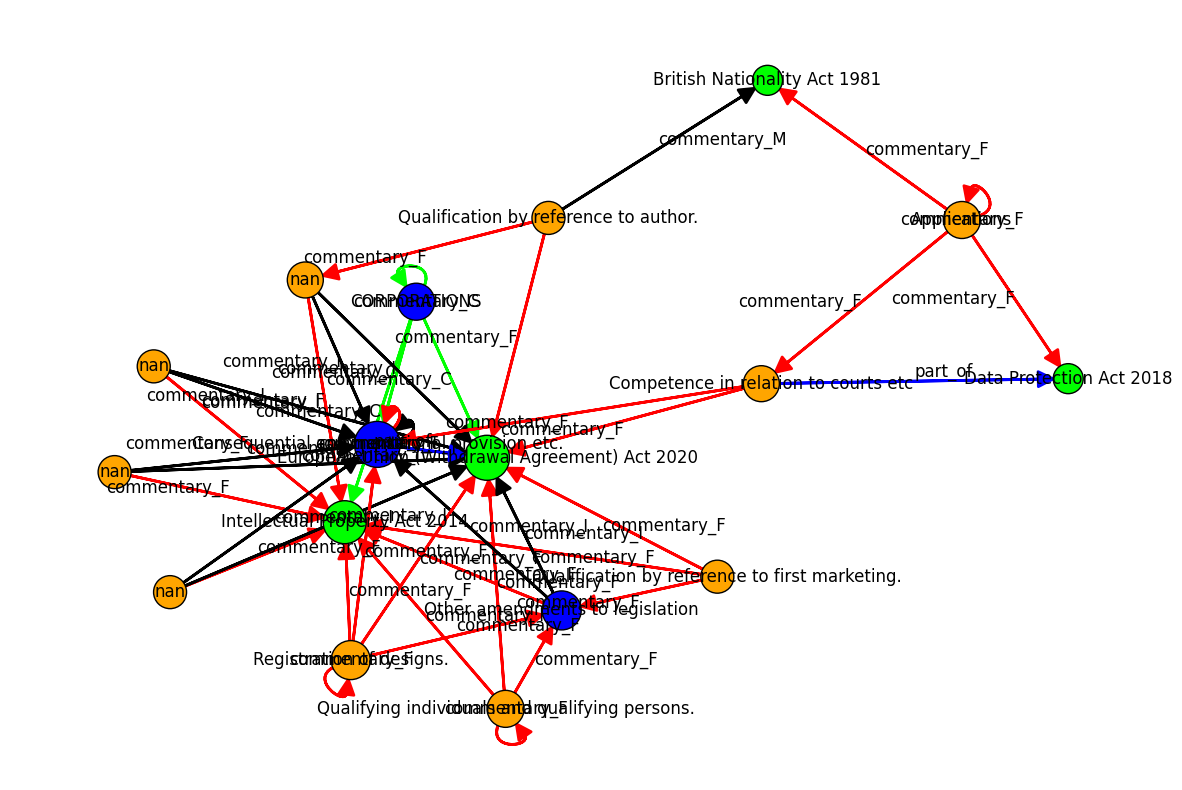

In [24]:
print("Path analysis between DPA 2018 and IP")
paths = path_analysis(plot_graph, DPA_vertex, IP_vertex)
print_paths_with_labels(plot_graph, paths, num_paths=5)
plot_paths(plot_graph, paths, num_paths=15)

Path analysis between DPA 1998 and IP
########################################
Path analysis between Data Protection Act 1998 and Intellectual Property Act 2014
Paths of length 1: 0 between Data Protection Act 1998 and Intellectual Property Act 2014
Paths of length 2: 0 between Data Protection Act 1998 and Intellectual Property Act 2014
Paths of length 3: 0 between Data Protection Act 1998 and Intellectual Property Act 2014
Paths of length 4: 170 between Data Protection Act 1998 and Intellectual Property Act 2014
Paths of length 5: 4866 between Data Protection Act 1998 and Intellectual Property Act 2014

Path:
Data Protection Act 1998 --rev_commentary_F--> Information Provisions -- Information Provisions --freetext_reference--> CAA's air navigation functions -- CAA's air navigation functions --rev_freetext_reference--> “Relevant firm” -- “Relevant firm” --rev_commentary_C--> CORPORATIONS -- CORPORATIONS --commentary_C--> Intellectual Property Act 2014

Path:
Data Protection Act 1998 --

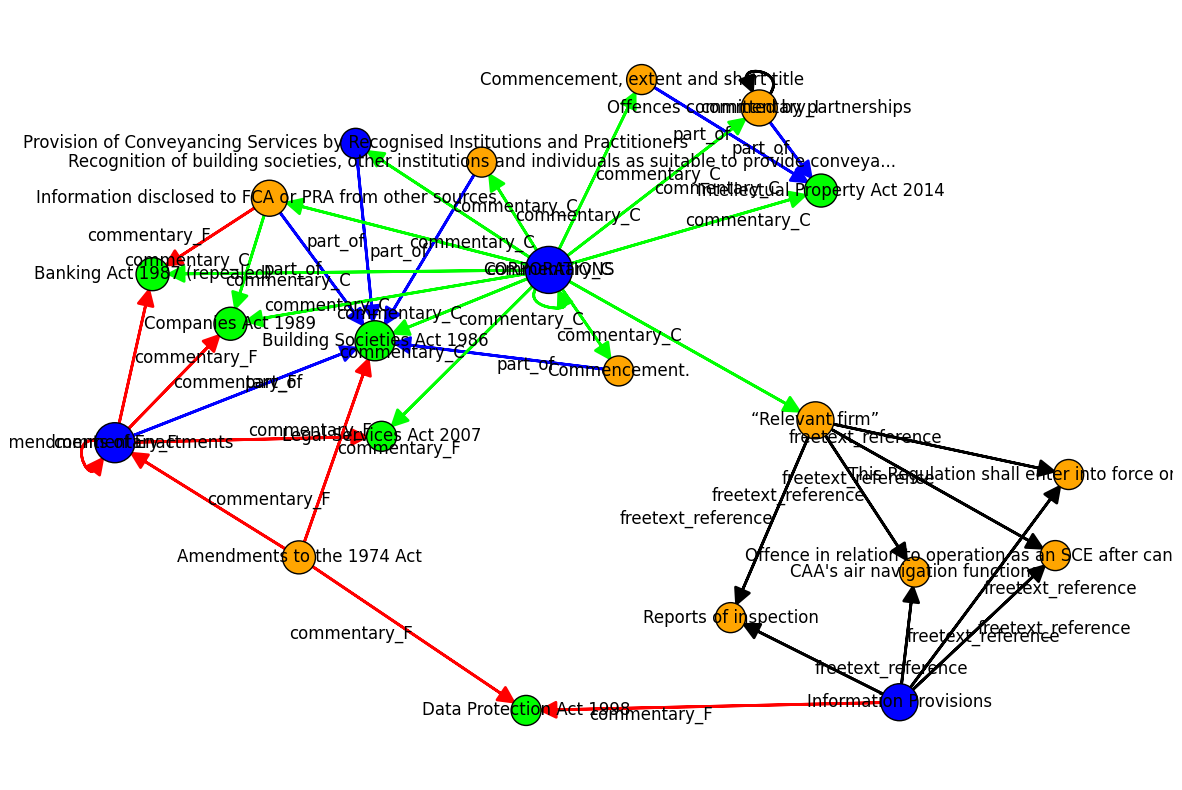

In [25]:
print("Path analysis between DPA 1998 and IP")
paths = path_analysis(plot_graph, DPA_98_vertex, IP_vertex)
print_paths_with_labels(plot_graph, paths, num_paths=5)
plot_paths(plot_graph, paths, num_paths=15)


In [26]:
# Using the entire UK legislation graph
DPA_vertex = g.vs.find(label="Data Protection Act 2018", type='legislation').index
DPA_98_vertex = g.vs.find(label="Data Protection Act 1998", type='legislation').index
IP_vertex = g.vs.find(label="Intellectual Property Act 2014", type='legislation').index


In [ ]:
print("Path analysis between DPA 2018 and IP")
paths = path_analysis(g, DPA_vertex, IP_vertex)
print_paths_with_labels(g, paths, num_paths=5)
plot_paths(g, paths, num_paths=15)

In [ ]:
print("Path analysis between DPA 1998 and IP")
paths = path_analysis(g, DPA_98_vertex, IP_vertex)
print_paths_with_labels(g, paths, num_paths=5)
plot_paths(g, paths, num_paths=15)